In [1]:
using CSV
using DataFrames
using DelimitedFiles
using CairoMakie
using LsqFit


In [2]:
messung_1_1 = readdlm("sensor1_1", '\t', Float64, skipstart = 2)
#=\t gibt an dass Julia da trennen soll wo die Spalten durch Tabulaor-Zeichen getrennt sind
ist nicht immer notwendig.
Da code im Seelber Ordner ist wie die Datei die ich will, brauche ich diesmal nichtt den 
Pfad, der name reicht.
=#

1506×2 Matrix{Float64}:
 2.01961e-5  0.0273931
 2.03131e-5  0.0273918
 2.02928e-5  0.0273909
 2.02153e-5  0.0273908
 2.02634e-5  0.0273915
 2.02193e-5  0.027392
 2.01249e-5  0.0273926
 2.00231e-5  0.0273923
 2.0026e-5   0.0273914
 1.99559e-5  0.0273915
 2.00706e-5  0.0273912
 2.00644e-5  0.0273916
 2.00254e-5  0.0273921
 ⋮           
 2.164e-5    0.027703
 2.16083e-5  0.0277035
 2.17185e-5  0.0276999
 2.16185e-5  0.0276951
 2.16473e-5  0.027692
 2.16575e-5  0.0276883
 2.1506e-5   0.0276875
 2.14641e-5  0.0276863
 2.14483e-5  0.0276844
 2.13352e-5  0.0276819
 2.13081e-5  0.0276806
 2.12782e-5  0.0276772

In [ ]:
U = messung_1_1[:,2]
U_x = messung_1_1[:,1]
I = U_x ./0.1


1506-element Vector{Float64}:
 2.01961266e-5
 2.03131476e-5
 2.02927968e-5
 2.02153478e-5
 2.02634001e-5
 2.02193041e-5
 2.01248949e-5
 2.00231389e-5
 2.00259656e-5
 1.99558654e-5
 2.00706254e-5
 2.00644063e-5
 2.00253999e-5
 ⋮
 2.16399567e-5
 2.1608299e-5
 2.17185352e-5
 2.16184744e-5
 2.16473054e-5
 2.16574808e-5
 2.15059754e-5
 2.14641423e-5
 2.14483116e-5
 2.13352487e-5
 2.1308113e-5
 2.12781506e-5

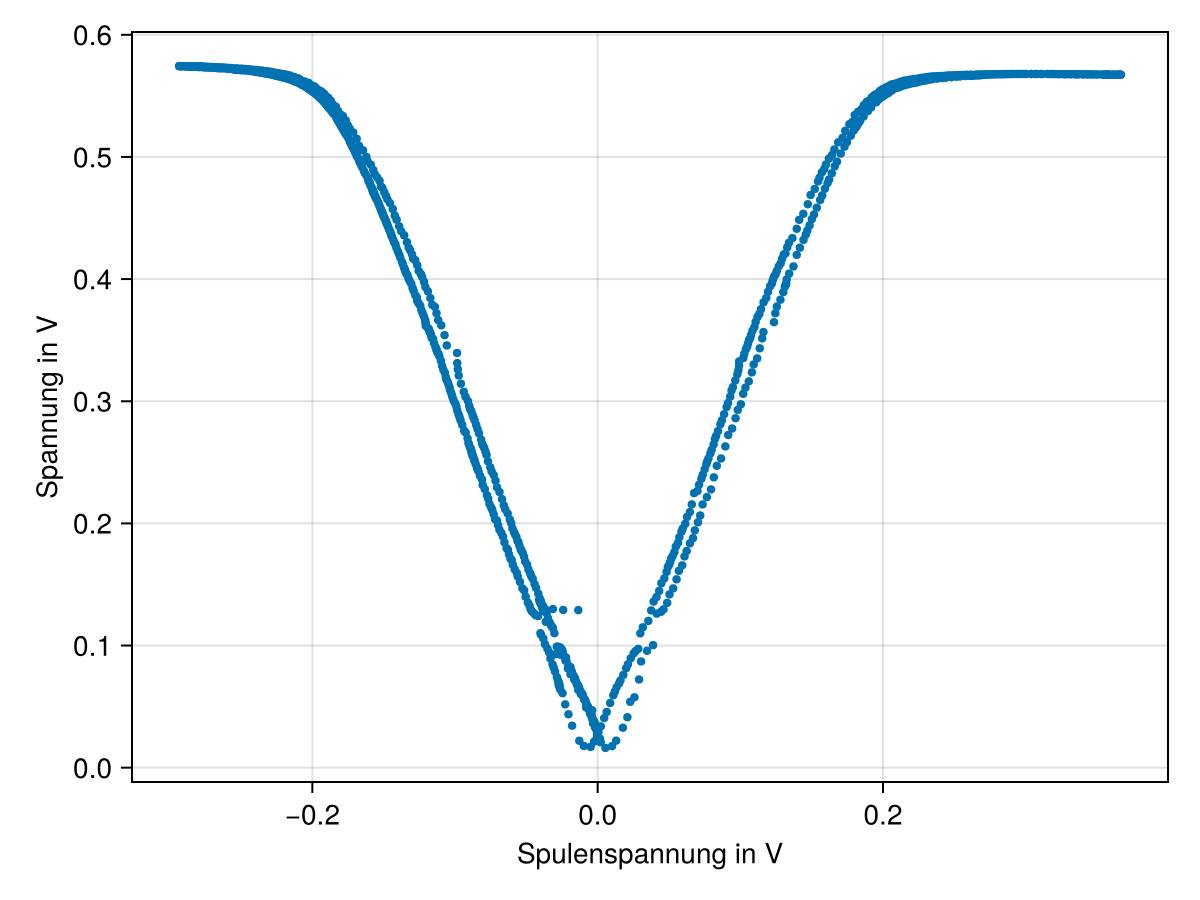

In [5]:
fig1 = Figure()
ax = Axis(fig1[1,1], xlabel = "Spulenspannung in V", ylabel = "Spannung in V")
scatter!(ax, U_x, U, markersize = 6)
fig1

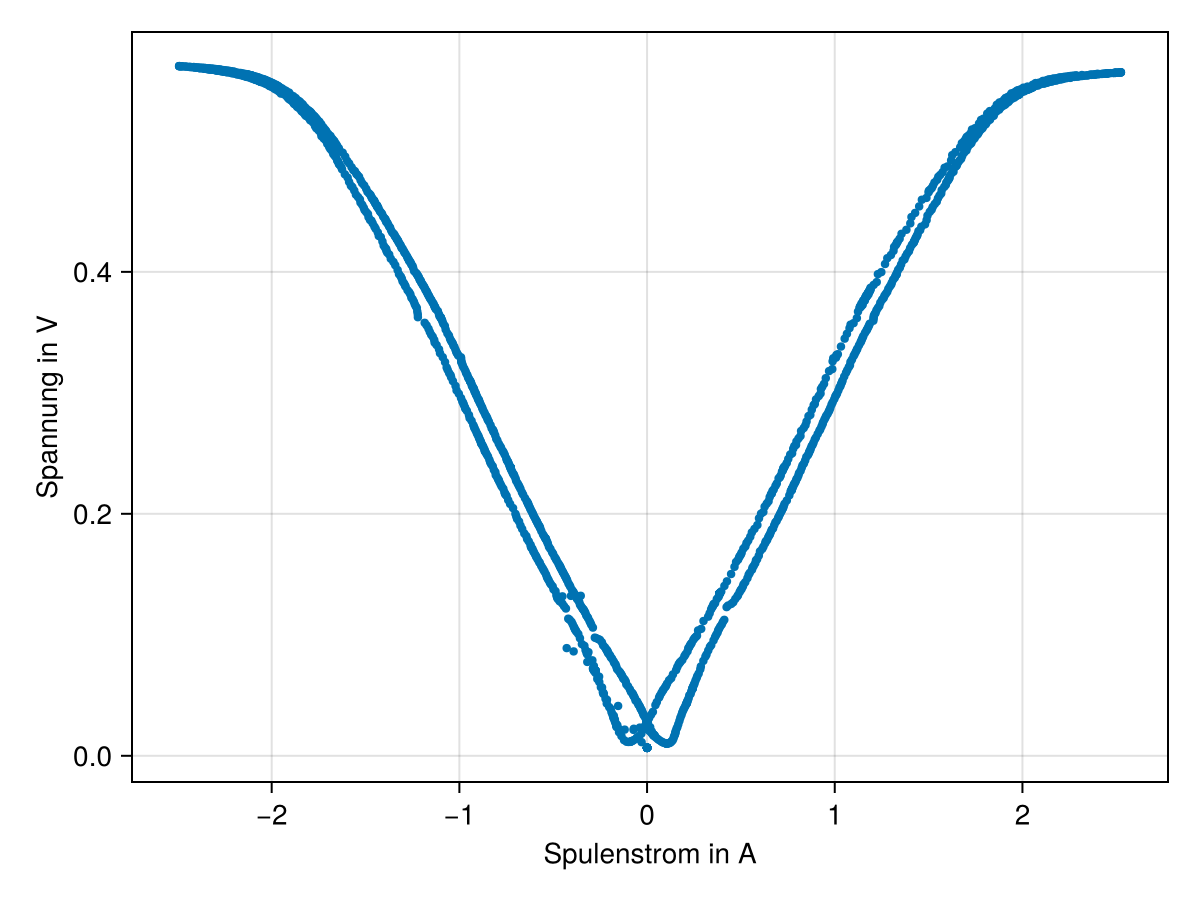

In [9]:
messung_1_2 = readdlm("sensor1_2", Float64, skipstart = 2)

Ux12 = messung_1_2[:,1] 
U12 = messung_1_2[:,2]
I12 = Ux12 ./0.1

fig2=Figure()
ax = Axis(fig2[1,1], xlabel="Spulenstrom in A", ylabel="Spannung in V")
scatter!(ax, I12, U12, markersize=6)
fig2
#Ich nehme das Zweite, da hier weniger geruckel auf den geraden ist




In [10]:
save("Spannung_vs_Strom_1_2_K.pdf", fig2)

CairoMakie.Screen{PDF}


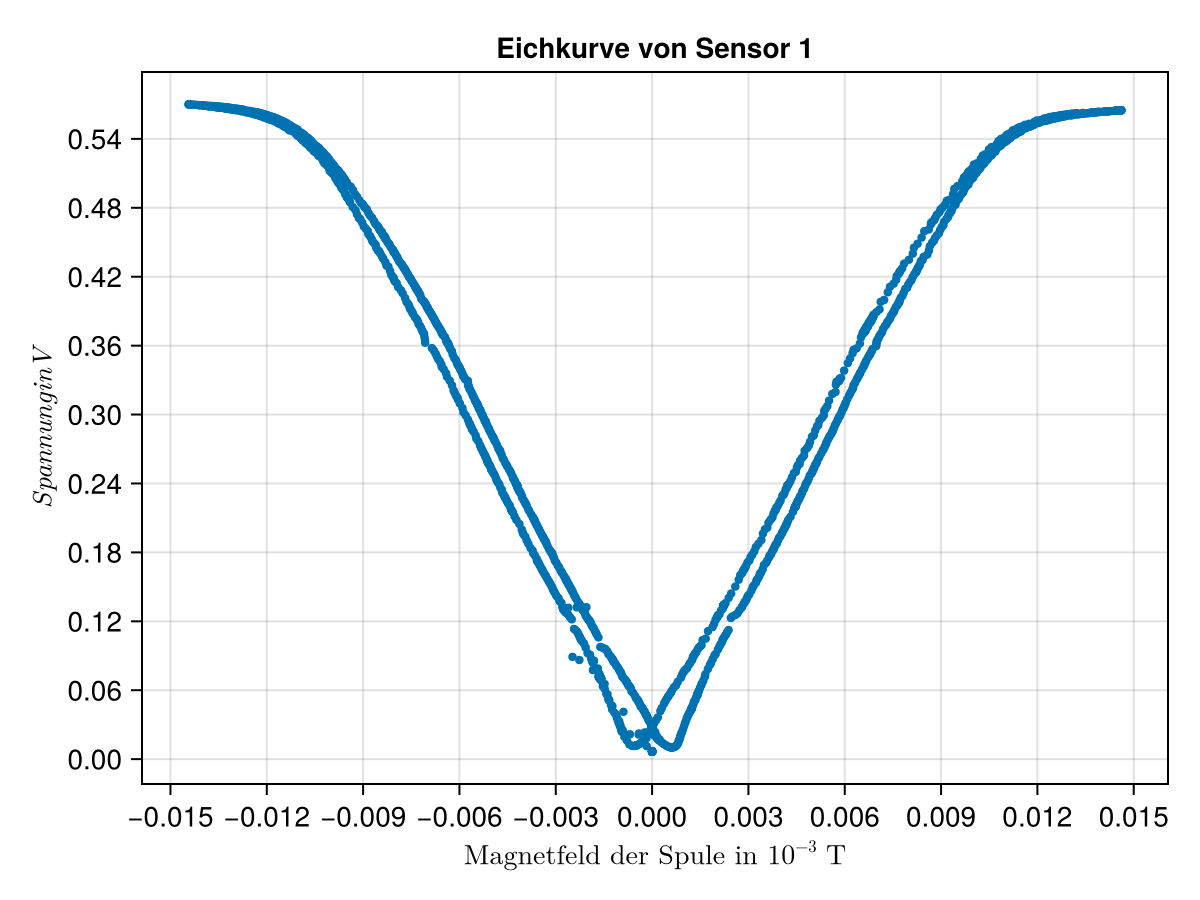

In [24]:
#B berechnen
N = 691
L = 0.15 # in m
μ0 = 4π*1e-7

B12 = I12 .* (μ0*N/L)
B12_skaliert = B12 #./ 1e-3 #Damit x-Achse nicht so voll, gröenordnung in beschritung

fig3 = Figure()
ax=Axis(fig3[1,1], xlabel= L"Magnetfeld der Spule in $10^{-3}$ T", ylabel=L"Spannung in V",
 title="Eichkurve von Sensor 1", xticks = LinearTicks(11), yticks = LinearTicks(11))
scatter!(ax, B12_skaliert, U12, markersize=6)
fig3

#L"..." aktiviert Latex

In [14]:
save("Eichkurve_Sensor_1_K.pdf",fig3)

CairoMakie.Screen{PDF}


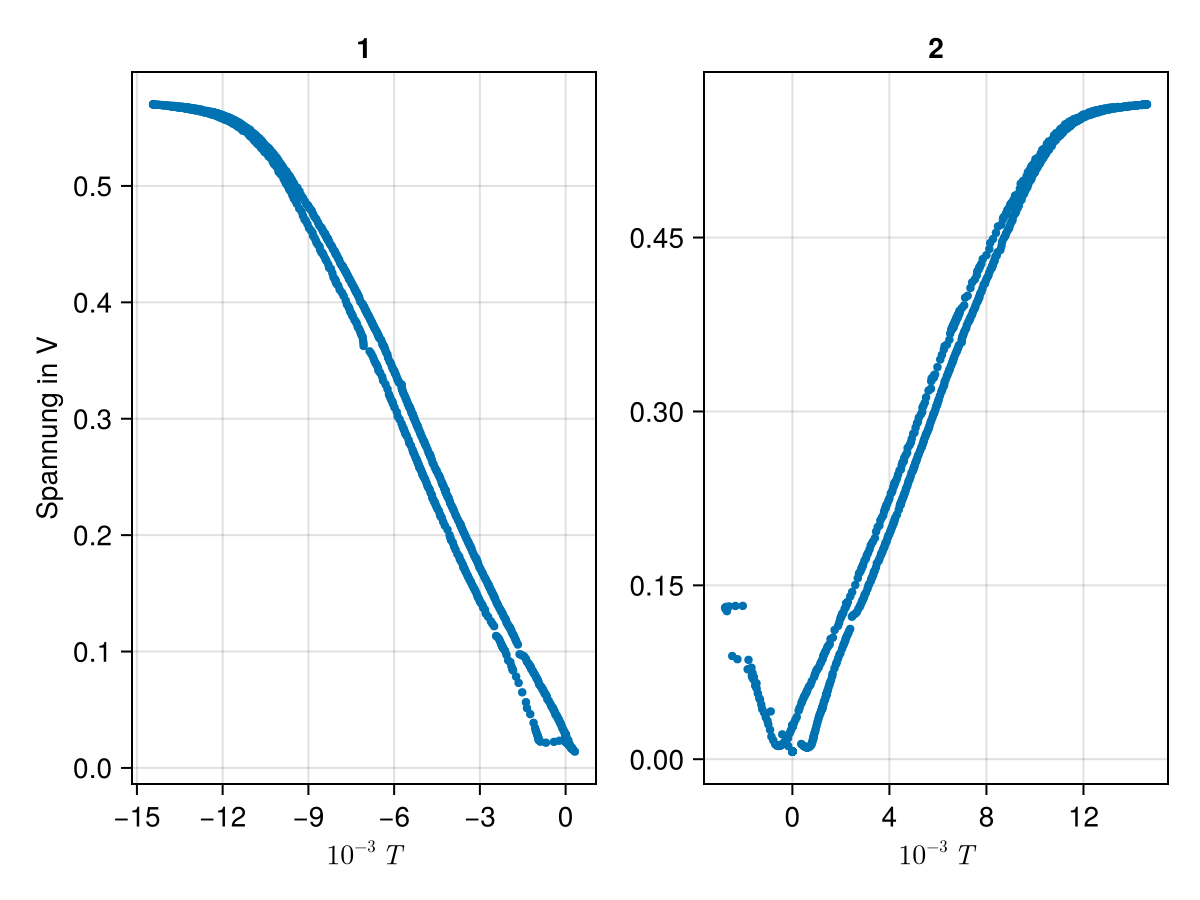

In [15]:
#Kurve in zwei Teile aufteilen mit pos und neg Steigung jeweils

länge = length(B12)
H = Int(länge /2)
#1. Hälfte, aufsteigend
U12_1 = U12[1:H]
B12_skaliert_1 = B12_skaliert[1:H]

#2.Hälft2, absteigend
U12_2 =U12[H+1:end]
B12_skaliert_2 = B12_skaliert[H+1:end]

fig5 = Figure()
ax1 = Axis(fig5[1,1], xlabel = L" 10^{-3}\:T", ylabel ="Spannung in V", title ="1",
xticks = LinearTicks(6), yticks = LinearTicks(7))
ax2 = Axis(fig5[1,2], xlabel = L" 10^{-3}\:T", title ="2", xticks = LinearTicks(6), 
yticks = LinearTicks(6))

CairoMakie.scatter!(ax1, B12_skaliert_1, U12_1, markersize=6)
CairoMakie.scatter!(ax2, B12_skaliert_2, U12_2, markersize=6)
fig5

In [18]:
mask_pos = (B12_skaliert_2 .>=1.5) .& (B12_skaliert_2 .<10)
mask_neg = (B12_skaliert_1 .>=-9) .& (B12_skaliert_1 .<-1.6)

x_fit_1 = B12_skaliert_1[mask_neg]
y_fit_1 = U12_1[mask_neg]

x_fit_2 = B12_skaliert_2[mask_pos]
y_fit_2 = U12_2[mask_pos];






Steigung m = -0.05392223534640795 ± 0.0003245916285943284
y-Abschnitt b =0.0014602983156398893 ± 0.0018438478547088805


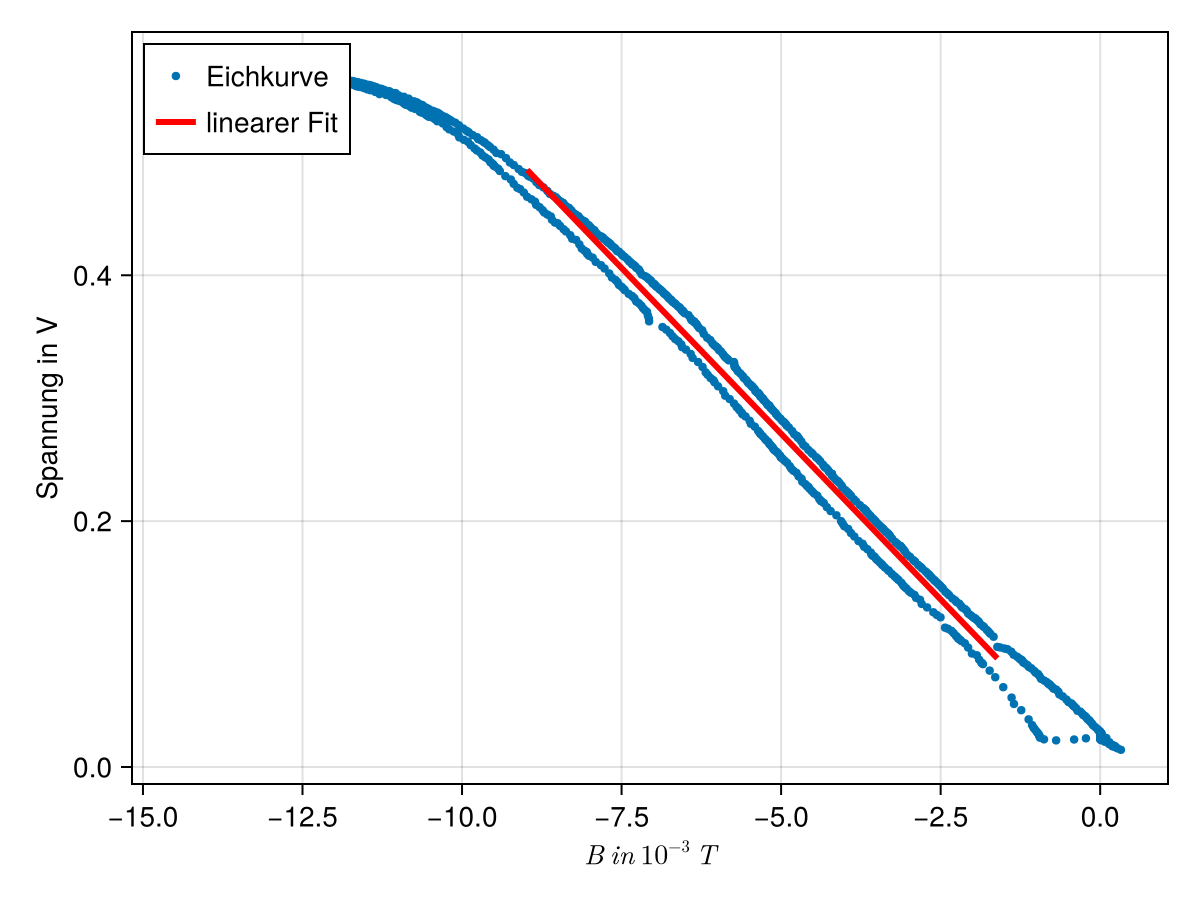

In [19]:
#fit1  durchführen 
@. gerade(x, p) = p[1]*x + p[2]
p0 = [-0.5, 0.0]
fit = curve_fit(gerade, x_fit_1, y_fit_1, p0)

#m und b geben lassen
m, b = fit.param
Δm, Δb = stderror(fit)

println("Steigung m = $m ± $Δm")
println("y-Abschnitt b =$b ± $Δb")

fig6= Figure()
ax = Axis(fig6[1,1], title = "" ,xlabel = L"B\: in\: 10^{-3}\:T ", ylabel = "Spannung in V",
xticks = LinearTicks(8))


scatter!(ax, B12_skaliert_1, U12_1, label = "Eichkurve", markersize = 6)


T_fit = range(minimum(x_fit_1 ), maximum(x_fit_1), length = 100)
y_fit = gerade(T_fit, fit.param)

lines!(ax, T_fit, y_fit, label = "linearer Fit", color = :red, linewidth = 3)

axislegend(ax, position = :lt)

fig6




Steigung m = 0.051957305291091896 ± 0.0003006991952007924
y-Abschnitt b =0.005676807673418177 ± 0.0018013020928830726


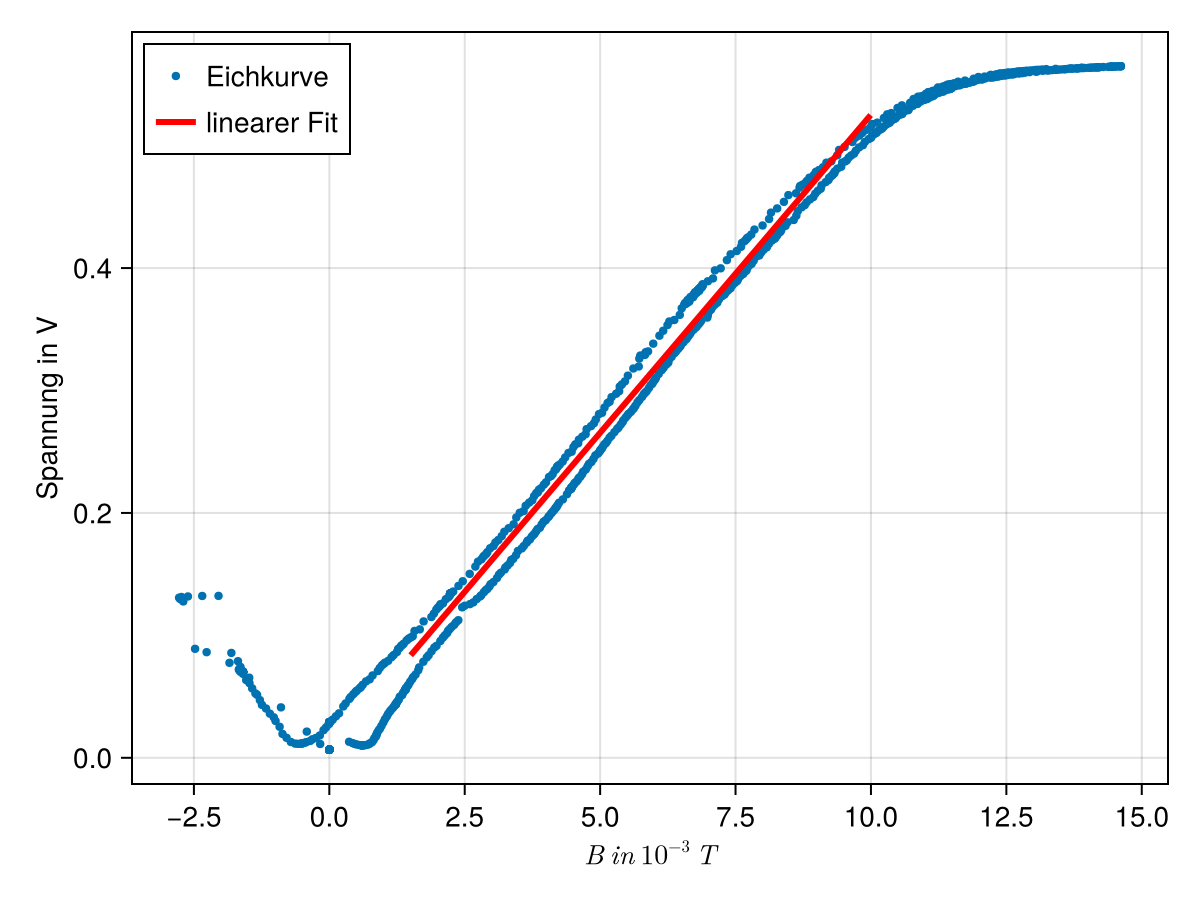

In [20]:
#fit2
@. gerade(x, p) = p[1]*x + p[2]
p0 = [0.5, 0.0]
fit = curve_fit(gerade, x_fit_2, y_fit_2, p0)

#m und b geben lassen
m, b = fit.param
Δm, Δb = stderror(fit)

println("Steigung m = $m ± $Δm")
println("y-Abschnitt b =$b ± $Δb")

fig7= Figure()
ax = Axis(fig7[1,1], title = "" ,xlabel = L"B\: in\: 10^{-3}\:T ", ylabel = "Spannung in V",
xticks = LinearTicks(8))


scatter!(ax, B12_skaliert_2, U12_2, label = "Eichkurve", markersize = 6)


T_fit = range(minimum(x_fit_2 ), maximum(x_fit_2), length = 100)
y_fit = gerade(T_fit, fit.param)

lines!(ax, T_fit, y_fit, label = "linearer Fit", color = :red, linewidth = 3)

axislegend(ax, position = :lt)

fig7



In [21]:
save("Fit_neg_Sensor_1_K.pdf",fig6)
save("Fit_pos_Sensor_1_K.pdf",fig7)

CairoMakie.Screen{PDF}
